# Zadanie 1: Fine-tuning zamrożonego modelu DINO na zbiorze CIFAR
Wczytaj z biblioteki timm zamrożony model: vit_base_patch16_224.dino

Wszystkie parametry backbone pozostaw zamrożone (requires_grad=False). Następnie wykonaj klasyfikację obrazów ze zbioru CIFAR przy użyciu dwóch różnych reprezentacji uzyskiwanych z Vision Transformera:
- wykorzystując wyłącznie reprezentację CLS tokena,
- wykorzystując średnią z wszystkich patch tokenów.

Dla każdego wariantu:
- dodaj odpowiednią głowicę klasyfikacyjną,
- przeprowadź fine-tuning wyłącznie głowicy,
- wytrenuj model na zbiorze CIFAR,
- porównaj wyniki klasyfikacji.
- przedstaw wykres przebiegu funkcji straty i dokładności,


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import timm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

device = torch.device("cpu")
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

full_train_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
subset_indices = list(range(1000))
train_subset = Subset(full_train_set, subset_indices)
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)

class ViTClassifier(nn.Module):
    def __init__(self, model_name, mode='cls'):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=True, num_classes=0)
        for param in self.backbone.parameters():
            param.requires_grad = False
        self.mode = mode
        self.head = nn.Linear(self.backbone.embed_dim, 10)

    def forward(self, x):
        with torch.no_grad():
            features = self.backbone.forward_features(x)
        x = features[:, 0] if self.mode == 'cls' else features[:, 1:].mean(dim=1)
        return self.head(x)

results = {}
for mode in ['cls', 'gap']:
    print(f"\n--- Szybki test DINO: {mode.upper()} ---")
    model = ViTClassifier('vit_base_patch16_224.dino', mode=mode).to(device)
    optimizer = optim.Adam(model.head.parameters(), lr=3e-4)
    criterion = nn.CrossEntropyLoss()

    model.train()
    total_loss = 0
    for i, (imgs, labels) in enumerate(train_loader):
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        if i % 10 == 0: print(f"Batch {i}/{len(train_loader)} Loss: {loss.item():.4f}")

    results[mode] = total_loss / len(train_loader)

print("\nŚredni loss:", results)


DINO: CLS
Batch 0/32 Loss: 2.8881
Batch 10/32 Loss: 2.1987
Batch 20/32 Loss: 1.8042
Batch 30/32 Loss: 1.0682

DINO: GAP
Batch 0/32 Loss: 2.8253
Batch 10/32 Loss: 2.2753
Batch 20/32 Loss: 2.1438
Batch 30/32 Loss: 2.0484

Średni loss: {'cls': 2.0058701541274786, 'gap': 2.2469124905765057}


# Zadanie 2: Wizualizacja map atencji modelu DINO
Dla modelu z poprzedniego zadania zwizualizuj mapy atencji pochodzące z ostatniej warstwy transformera.
- pobierz mapy atencji ostatniej głowy atencji,
- zwizualizuj atencję pochodzącą od CLS tokena do wszystkich patchy obrazu,
- przeskaluj otrzymaną mapę do rozmiaru wejściowego obrazu,
- nałóż mapę atencji na obraz wejściowy.


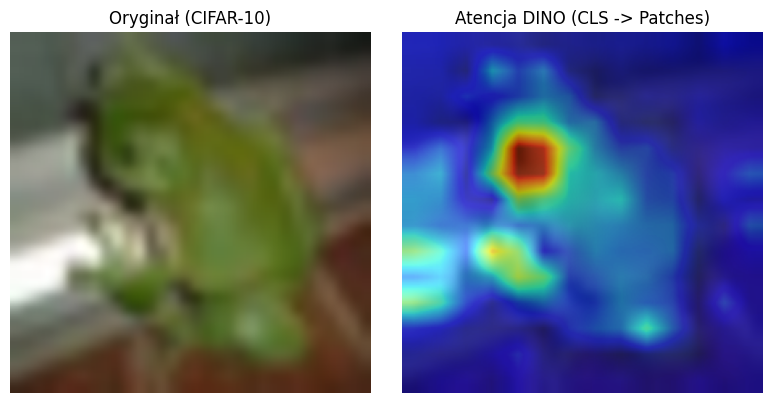

In [5]:
import torch
import timm
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
import torch.nn.functional as F

device = torch.device("cuda")
model = timm.create_model('vit_base_patch16_224.dino', pretrained=True).to(device).eval()

img_raw, _ = datasets.CIFAR10(root='./data', train=False, download=True)[7]
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
img_t = transform(img_raw).unsqueeze(0).to(device)

attentions = []
def hook_fn(module, input, output):
    x = input[0]
    B, N, C = x.shape
    qkv = module.qkv(x).reshape(B, N, 3, module.num_heads, -1).permute(2, 0, 3, 1, 4)
    q, k, v = qkv[0], qkv[1], qkv[2]

    attn = (q @ k.transpose(-2, -1)) * module.scale
    attn = attn.softmax(dim=-1)
    attentions.append(attn)

handle = model.blocks[-1].attn.register_forward_hook(hook_fn)

with torch.no_grad():
    _ = model(img_t)
handle.remove()

attn = attentions[0][0].mean(dim=0)

cls_attn = attn[0, 1:].reshape(14, 14).detach().cpu()

cls_attn = cls_attn.unsqueeze(0).unsqueeze(0) # [1, 1, 14, 14]
cls_attn = F.interpolate(cls_attn, size=(224, 224), mode='bilinear', align_corners=False)[0, 0]

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_raw.resize((224, 224)))
plt.title("Oryginał (CIFAR-10)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_raw.resize((224, 224)))
plt.imshow(cls_attn, cmap='jet', alpha=0.6)
plt.title("Atencja DINO (CLS -> Patches)")
plt.axis('off')

plt.tight_layout()
plt.show()

# Zadanie 3: Powtórzenie eksperymentów dla Masked AutoEncodera (MAE)
Powtórz zadania 1 i 2 dla modelu typu Masked AutoEncoder (MAE) dostępnego w bibliotece timm.
- pobierz odpowiedni model MAE,
- wykonaj porównanie klasyfikacji z CLS tokena,
- klasyfikacji ze średniej patch tokenów,
- zwizualizuj mapy atencji ostatniej warstwy,



--- MAE: CLS ---
E1 Acc: 0.220
E2 Acc: 0.371
E3 Acc: 0.423
E4 Acc: 0.471
E5 Acc: 0.540

--- MAE: GAP ---
E1 Acc: 0.211
E2 Acc: 0.364
E3 Acc: 0.492
E4 Acc: 0.566
E5 Acc: 0.559


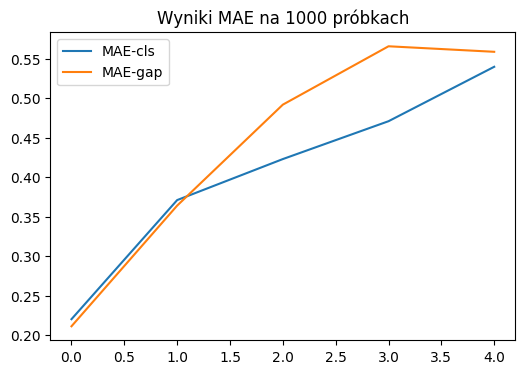

In [7]:
import torch
import torch.nn as nn
import timm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

device = torch.device("cuda")

results_mae = {}
for mode in ['cls', 'gap']:
    print(f"\n--- MAE: {mode.upper()} ---")
    backbone = timm.create_model('vit_base_patch16_224.mae', pretrained=True, num_classes=0).to(device)
    for p in backbone.parameters(): p.requires_grad = False

    head = nn.Linear(backbone.embed_dim, 10).to(device)
    optimizer = torch.optim.Adam(head.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    accs = []
    for epoch in range(5):
        ok = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.no_grad():
                feat = backbone.forward_features(imgs)
            x = feat[:, 0] if mode == 'cls' else feat[:, 1:].mean(dim=1)
            out = head(x)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            ok += (out.argmax(1) == labels).sum().item()
        accs.append(ok/1000)
        print(f"E{epoch+1} Acc: {accs[-1]:.3f}")
    results_mae[mode] = accs

plt.figure(figsize=(6, 4))
for m, acc in results_mae.items(): plt.plot(acc, label=f"MAE-{m}")
plt.title("Wyniki MAE na 1000 próbkach"); plt.legend(); plt.show()